# Tutoriel 6

[Télécharger le tutoriel](../06_tutoriel.zip)

# Se familiariser avec le décentrage « upwind »

L'advection pose un problème que la diffusion ne posait pas : **il faut décider dans quel sens aller chercher l'information**, et ce choix dépend du signe de la vitesse. Se tromper ne donne pas un résultat « un peu moins bon » : cela fait **exploser** le modèle en quelques dizaines d'itérations.

## 1. Le terme d'advection fait perdre une cellule

L'équation d'advection, $\frac{\partial C}{\partial t} = - V_x \frac{\partial C}{\partial x}$, ne contient qu'**une seule** dérivée en espace :

```python
dCdt_a = - Vx * ( C[1:] - C[:-1] ) / dx      # taille nx-1
```

Le résultat est de taille `nx-1`, alors que `C` est de taille `nx`.

Il faut donc choisir **quelles** cellules de `C` mettre à jour, et il n'y a que deux possibilités :

```python
C[1:]  += dt * dCdt_a      # on decale vers la droite
C[:-1] += dt * dCdt_a      # on decale vers la gauche
```

**Les deux écritures sont numériquement valides** — Python ne signalera aucune erreur.

## 2. Le bon choix dépend du sens du courant ("upwind")

L'idée du décentrage « upwind » (littéralement *face au vent*) est d'aller chercher l'information **en amont**, là d'où le courant arrive :

$$
\frac{C_i^{n+1} - C_i^n}{dt} =
\begin{cases}
-V_x \dfrac{C_i^n - C_{i-1}^n}{dx} & \text{si } V_x > 0 \quad \text{(on regarde à gauche)} \\[2mm]
-V_x \dfrac{C_{i+1}^n - C_i^n}{dx} & \text{sinon} \quad\quad\ \ \text{(on regarde à droite)}
\end{cases}
$$

| Choix | | mise à jour | |
|---|---|---|---|
| 1 | $V_x > 0$, le courant va vers la **droite** | `C[1:] += dt * dCdt_a` | indices `1:` |
| 2 | $V_x < 0$, le courant va vers la **gauche** | `C[:-1] += dt * dCdt_a` | indices `:-1` |

Un polluant a été déversé dans une rivière et forme un pic de concentration ; le courant l'emporte vers l'aval à `Vx = 0.5` m/s. Le bon choix est donc `C[1:]`.

**À vous de vérifier les deux.** Dans la cellule ci-dessous, la variable `choix` décide de la mise à jour utilisée : `choix = 1` pour `C[1:]`, `choix = 2` pour `C[:-1]`. Exécutez la cellule telle quelle, puis passez `choix` à `2` et ré-exécutez.

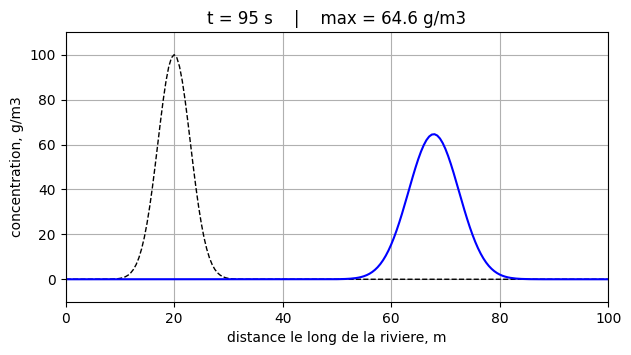

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

choix = 1       # <<< CHANGEZ CETTE LIGNE :  1 -> C[1:]   ou   2 -> C[:-1]

# parametres physiques
Lx = 100.0      # longueur du troncon de riviere, m
Vx = 0.5        # vitesse du courant, m/s

# parametres numeriques
nx = 201        # nombre de points
freq_affich = 10

# initialisation
x     = np.linspace(0, Lx, nx)
dx    = Lx/(nx-1)
dt    = dx/(2.1*abs(Vx))            # contrainte de stabilite de l'advection
nt    = int(100.0/dt)               # 100 secondes simulees
C_ini = 100*np.exp(-(x-20)**2/18)   # un pic de polluant centre a x = 20 m
C     = np.copy(C_ini)

fig, ax = plt.subplots(figsize=(7,3.5))

for it in range(nt):

    dCdt_a = - Vx*( C[1:] - C[:-1] )/dx
    if choix == 1:
        C[1:]  += dt*dCdt_a         # on decale vers la droite
    else:
        C[:-1] += dt*dCdt_a         # on decale vers la gauche

    if it % freq_affich == 0:
        maxi = round(np.max(np.abs(C)), 1)
        clear_output(wait=True)
        ax.cla()
        ax.plot(x, C_ini, 'k--', linewidth=1)
        ax.plot(x, C, 'b')
        ax.set_xlim([0, Lx])
        ax.set_ylim([-10, 110])
        ax.set_xlabel('distance le long de la riviere, m')
        ax.set_ylabel('concentration, g/m3')
        ax.set_title('t = ' + str(round(it*dt)) + ' s    |    max = ' + str(maxi) + ' g/m3')
        ax.grid(True)
        display(fig)
        plt.pause(0.02)

plt.close()

Avec `choix = 1`, le pic traverse tranquillement la rivière et se déplace de $V_x \times t = 0.5 \times 100 = 50$ m vers l'aval : c'est exactement ce que l'on attendait, et le maximum affiché dans le titre reste de l'ordre de 100 g/m³.

Avec `choix = 2`, **regardez le maximum dans le titre défiler** : il grimpe à des valeurs astronomiques en quelques dizaines d'itérations, et la courbe sort immédiatement du cadre. Le modèle a explosé — et les concentrations négatives qu'il produit n'ont évidemment aucun sens physique.

**Retenez ce réflexe : si votre modèle d'advection explose ou produit des valeurs négatives, vérifiez d'abord le sens du décalage.**